Plot ROP Coverage by Frame
---

In [1]:
import geopandas as gpd
import pandas as pd
import fiona
from matplotlib import pyplot as plt
import shapely
from shapely.geometry import Polygon, MultiPolygon
import numpy as np
import os
fiona.drvsupport.supported_drivers['LIBKML'] = 'rw'
#from datetime import datetime
import pytz
import warnings

## Read Geopackage and Filter Antarctica Frames

In [2]:
ROPfile ='ROP/Processed_Compressed/ROP356_cycle028.gpkg'
#ROPfile = 'track-frame/MPREFOBS349_qvis_cycle011.gpkg'
if '356' in ROPfile:
    modeKey = 'radar_mode_name_list'
    color='r'
elif '349' in ROPfile:
    modeKey = 'radar_mode_name'
    color = 'b'
else:
    print('Invalide ROP')
ROBc7 = gpd.read_file(ROPfile, bbox=(-180, -90, 180,-48))
subset = ROBc7[(ROBc7['epsg'] == 3031) & (ROBc7['produceROFF'] == True)]

Filter all frames that have 80 or 40 MHz. Note some frames will appear in both the 40/80 list when there is a mode transition.

In [3]:
# All

icesheetFrames = subset[subset[modeKey].str.contains('L_40|L_80', na=False)]
print(f'total frames: {icesheetFrames.shape[0]}')
# All Asc/Desc
icesheetFramesAsc =  icesheetFrames[icesheetFrames['passDirection'].str.contains('Ascending', na=False)]
icesheetFramesDesc = icesheetFrames[icesheetFrames['passDirection'].str.contains('Descending', na=False)]
print(f'total frames  Asc: {icesheetFramesAsc.shape[0]}  Desc:  {icesheetFramesDesc.shape[0]} ')
# All 40 and 80

icesheetFrames40 =  icesheetFrames[icesheetFrames[modeKey].str.contains('L_40', na=False)]
icesheetFrames80 =  icesheetFrames[icesheetFrames[modeKey].str.contains('L_80', na=False)]
print(f'total frames  40: {icesheetFrames40.shape[0]}  80: {icesheetFrames80.shape[0]} ')
# All 40 and 80 by Asc/Desc
icesheetFrames40Asc = icesheetFrames40[icesheetFrames40['passDirection'].str.contains('Ascending', na=False)]
icesheetFrames40Desc = icesheetFrames40[icesheetFrames40['passDirection'].str.contains('Descending', na=False)]
icesheetFrames80Asc = icesheetFrames80[icesheetFrames80['passDirection'].str.contains('Ascending', na=False)]
icesheetFrames80Desc = icesheetFrames80[icesheetFrames80['passDirection'].str.contains('Descending', na=False)]
print(f'total frames Asc  40: {icesheetFrames40Asc.shape[0]}  80: {icesheetFrames80Asc.shape[0]} ')
print(f'total frames Desc  40: {icesheetFrames40Desc.shape[0]}  80: {icesheetFrames80Desc.shape[0]} ')
#
icesheetFramesDual = icesheetFrames[
    icesheetFrames[modeKey].str.contains('L_40', na=False) &
    icesheetFrames[modeKey].str.contains('L_80', na=False)
]
print(f'total dual frames: {icesheetFramesDual .shape[0]} ')

total frames: 1448
total frames  Asc: 959  Desc:  489 
total frames  40: 701  80: 861 
total frames Asc  40: 314  80: 752 
total frames Desc  40: 387  80: 109 
total dual frames: 114 


## Plot Results

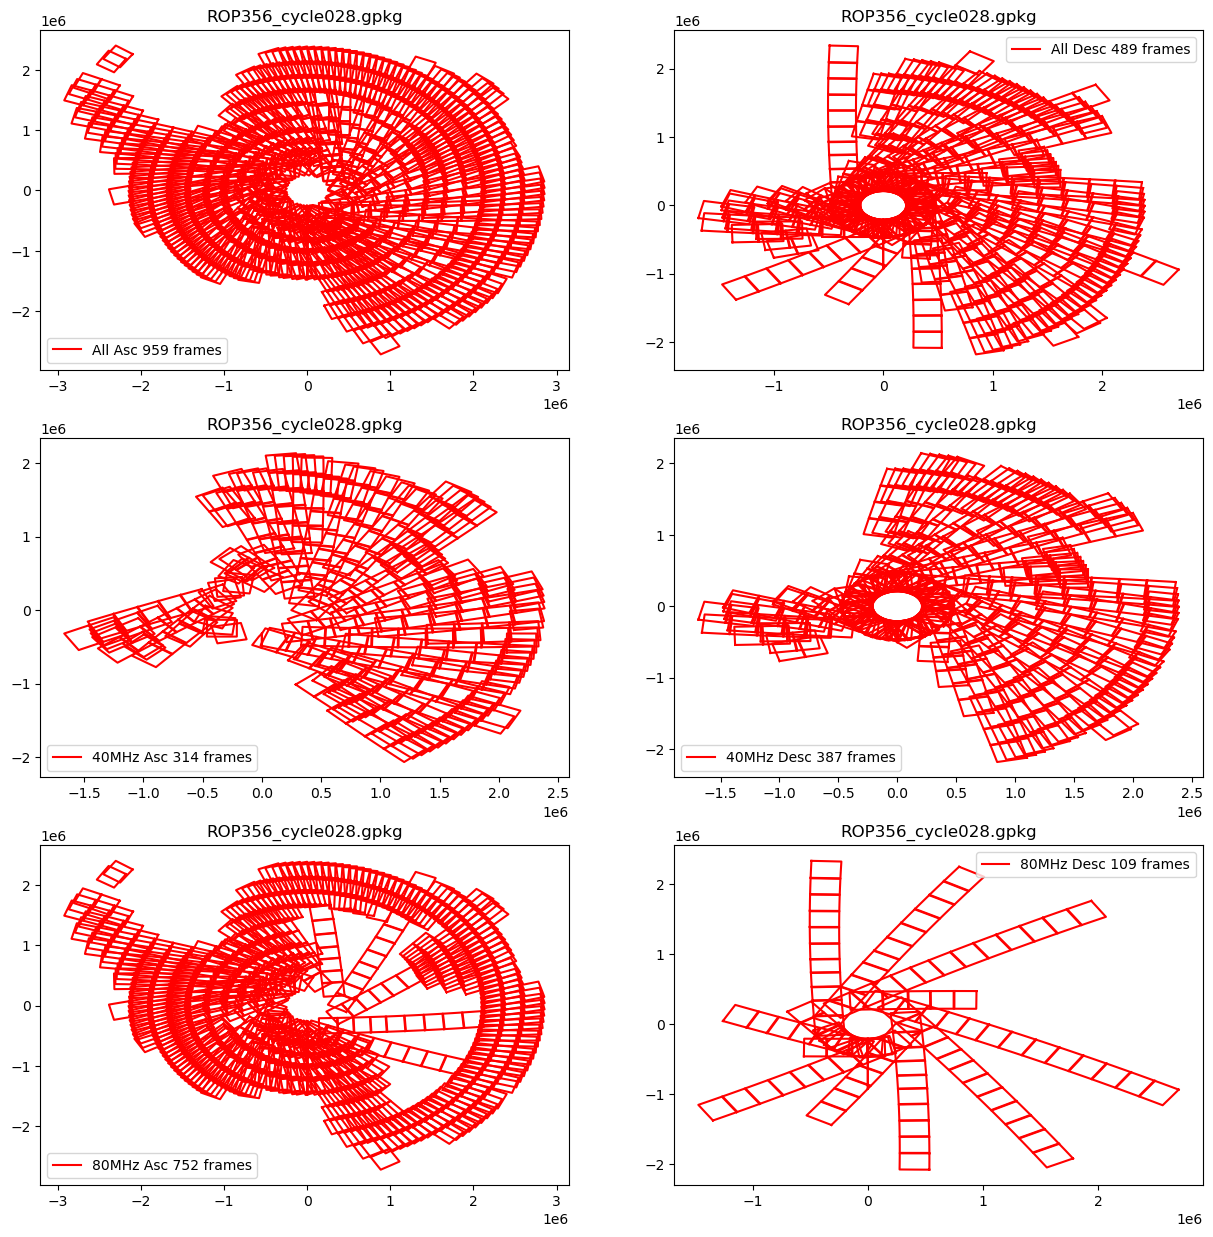

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
labels = [['All Asc', 'All Desc'], ['40MHz Asc', '40MHz Desc'], ['80MHz Asc', '80MHz Desc']]
for dataR, axR, labelR in zip([[icesheetFramesAsc, icesheetFramesDesc], 
                       [icesheetFrames40Asc, icesheetFrames40Desc], 
                       [icesheetFrames80Asc, icesheetFrames80Desc]], 
                        axes, labels):
    # 
    for data, ax, label in zip(dataR, axR, labelR):
        label = f'{label} {data.shape[0]} frames'
        data3031 = data.to_crs(epsg=3031)
        for row in data3031.iterrows():
            geom = row[1]['geometry']
            for poly in geom.geoms:
                ax.plot(*poly.exterior.xy, color=color, label=label)
                label = None
        ax.legend()
        ax.set_title(os.path.basename(ROPfile))